In [1]:
from pathlib import Path
import pandas as pd

try:
    folder = Path(__file__).resolve().parent
except NameError:
    folder = Path.cwd()

print("Looking in:", folder)
print("CSV files here:", [p.name for p in folder.glob("*.csv")])

df = pd.read_csv(folder / "online_retail_II.csv", encoding="ISO-8859-1")

# Rename columns to match the rest of the project
df = df.rename(columns={
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID",
})

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df.shape)
print(df.columns.tolist())
print(df.head())

Looking in: c:\Users\sv2707920\OneDrive - Surbana Jurong Private Limited\Desktop\Data Science\Portfolio - Projects\Online Retail - Project
CSV files here: ['online_retail_II.csv']
(1067371, 8)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
  InvoiceNo StockCode                          Description  Quantity  \
0    489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1    489434    79323P                   PINK CHERRY LIGHTS        12   
2    489434    79323W                  WHITE CHERRY LIGHTS        12   
3    489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4    489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2009-12-01 07:45:00       6.95     13085.0  United Kingdom  
1 2009-12-01 07:45:00       6.75     13085.0  United Kingdom  
2 2009-12-01 07:45:00       6.75     13085.0  United Kingdom  
3 2009-12-01 07

In [2]:
df.info()
print()
print(df[["Quantity", "UnitPrice"]].describe())
print()
print("Missing values:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Cancelled invoices:", df["InvoiceNo"].str.startswith("C").sum())
print("Date range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   UnitPrice    1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

           Quantity     UnitPrice
count  1.067371e+06  1.067371e+06
mean   9.938898e+00  4.649388e+00
std    1.727058e+02  1.235531e+02
min   -8.099500e+04 -5.359436e+04
25%    1.000000e+00  1.250000e+00
50%    3.000000e+00  2.100000e+00
75%    1.000000e+01  4.150000e+00
max    8.099500e+04  3.

In [3]:
print("Zero-price rows:", (df["UnitPrice"] == 0).sum())
print("Negative-quantity rows NOT starting with C:",
      ((df["Quantity"] < 0) & ~df["InvoiceNo"].str.startswith("C")).sum())
print()
print("Rows with price below 0:")
print(df[df["UnitPrice"] < 0][["InvoiceNo", "Description", "UnitPrice"]])
print()
print("10 most expensive rows:")
print(df.nlargest(10, "UnitPrice")[["InvoiceNo", "Description", "UnitPrice"]])

Zero-price rows: 6202
Negative-quantity rows NOT starting with C: 3457

Rows with price below 0:
       InvoiceNo      Description  UnitPrice
179403   A506401  Adjust bad debt  -53594.36
276274   A516228  Adjust bad debt  -44031.79
403472   A528059  Adjust bad debt  -38925.87
825444   A563186  Adjust bad debt  -11062.06
825445   A563187  Adjust bad debt  -11062.06

10 most expensive rows:
        InvoiceNo   Description  UnitPrice
748142    C556445        Manual   38970.00
241824    C512770        Manual   25111.09
241827     512771        Manual   25111.09
320581    C520667  Bank Charges   18910.69
1050063   C580605    AMAZON FEE   17836.46
569163    C540117    AMAZON FEE   16888.02
569164    C540118    AMAZON FEE   16453.71
517953    C537630    AMAZON FEE   13541.33
517955     537632    AMAZON FEE   13541.33
519294    C537651    AMAZON FEE   13541.33


In [5]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [6]:
# Online Retail project: Day 2 (cleaning)
# Run this in the SAME notebook as Day 1, after `df` has been loaded and renamed.
# Each "# %%" block is one cell. `df` is never changed, so you can re-run safely.

# %% Cell 1: Setup
from pathlib import Path
import pandas as pd

try:
    folder = Path(__file__).resolve().parent
except NameError:
    folder = Path.cwd()

work = df.copy()          # raw data stays untouched in `df`
start_rows = len(work)
log = []

def record(step, before, after):
    log.append({"step": step, "rows_before": before,
                "rows_after": after, "rows_removed": before - after})
    print(f"{step}: removed {before - after:,} rows -> {after:,} left")

# %% Cell 2: Step 1 - remove exact duplicates
before = len(work)
work = work.drop_duplicates()
record("1. Remove duplicate rows", before, len(work))

# %% Cell 3: Step 2 - set cancellations aside (invoice starts with "C")
is_cancel = work["InvoiceNo"].str.startswith("C")
cancellations = work[is_cancel].copy()
before = len(work)
work = work[~is_cancel].copy()
record("2. Set aside cancelled invoices", before, len(work))

# %% Cell 4: Step 3 - remove rows with no description
before = len(work)
work = work.dropna(subset=["Description"])
record("3. Remove missing descriptions", before, len(work))

# %% Cell 5: Step 4 - remove zero/negative quantity and price
# Catches the 3,457 negative-quantity rows without a "C", the 6,202
# zero-price rows, and the 5 "Adjust bad debt" negative prices.
before = len(work)
work = work[(work["Quantity"] > 0) & (work["UnitPrice"] > 0)]
record("4. Remove zero/negative quantity or price", before, len(work))

# %% Cell 6: Step 5 - remove non-product entries (postage, fees, adjustments)
# These are charges and accounting entries, not products the shop sells.
work["StockCode"] = work["StockCode"].astype(str).str.strip()
code = work["StockCode"].str.upper()

non_product_codes = ["POST", "DOT", "M", "BANK CHARGES", "AMAZONFEE",
                     "ADJUST", "ADJUST2", "B", "CRUK", "D", "S", "C2", "PADS"]
is_non_product = (
    code.isin(non_product_codes)
    | code.str.startswith("TEST")
    | code.str.startswith("GIFT")
)

# Check what is being removed before trusting it
print("Non-product entries found:")
print(work[is_non_product]["Description"].value_counts().head(15))

before = len(work)
work = work[~is_non_product]
record("5. Remove non-product entries", before, len(work))

# %% Cell 7: New columns
work["Revenue"] = work["Quantity"] * work["UnitPrice"]
work["Month"] = work["InvoiceDate"].dt.to_period("M").astype(str)
work["Weekday"] = work["InvoiceDate"].dt.day_name()
work["Hour"] = work["InvoiceDate"].dt.hour

# %% Cell 8: Sanity checks (all should pass)
assert (work["Quantity"] > 0).all()
assert (work["UnitPrice"] > 0).all()
assert not work["InvoiceNo"].str.startswith("C").any()
assert work["Description"].notna().all()
print("All checks passed.")

# %% Cell 9: Summary for your write-up
log_df = pd.DataFrame(log)
print("\nCLEANING LOG")
print(log_df.to_string(index=False))

print(f"\nStarted with {start_rows:,} rows, ended with {len(work):,} clean sales rows "
      f"({len(work) / start_rows:.1%} kept).")
print(f"Cancellation rows set aside: {len(cancellations):,}")
print(f"Total revenue (clean): {work['Revenue'].sum():,.2f}")
print(f"Clean rows with no CustomerID: {work['CustomerID'].isna().sum():,} "
      f"({work['CustomerID'].isna().mean():.1%})")
print(f"Date range: {work['InvoiceDate'].min()} to {work['InvoiceDate'].max()}")

# %% Cell 10: Save for Days 3-4
work.to_csv(folder / "clean_sales.csv", index=False)
cancellations.to_csv(folder / "cancellations.csv", index=False)
log_df.to_csv(folder / "cleaning_log.csv", index=False)
print("\nSaved to:", folder)

1. Remove duplicate rows: removed 34,335 rows -> 1,033,036 left
2. Set aside cancelled invoices: removed 19,104 rows -> 1,013,932 left
3. Remove missing descriptions: removed 4,275 rows -> 1,009,657 left
4. Remove zero/negative quantity or price: removed 1,744 rows -> 1,007,913 left
Non-product entries found:
Description
POSTAGE                                1851
DOTCOM POSTAGE                         1415
Manual                                  851
CARRIAGE                                267
Bank Charges                             32
Dotcomgiftshop Gift Voucher Â£20.00      26
Dotcomgiftshop Gift Voucher Â£30.00      24
Adjustment by john on 26/01/2010 16      20
PADS TO MATCH ALL CUSHIONS               17
Adjustment by john on 26/01/2010 17      16
Dotcomgiftshop Gift Voucher Â£10.00      14
This is a test product.                  10
Dotcomgiftshop Gift Voucher Â£50.00       6
Discount                                  5
Dotcomgiftshop Gift Voucher Â£40.00       5
Name: count, dtyp

In [7]:
# Online Retail project: Day 3 (four business questions)
# Two years of data (1 Dec 2009 to 9 Dec 2011), so we can compare years.
# Run cell by cell in your project folder, after Day 2 created clean_sales.csv.

# %% Cell 1: Load the clean data
from pathlib import Path
import pandas as pd

try:
    folder = Path(__file__).resolve().parent
except NameError:
    folder = Path.cwd()

sales = pd.read_csv(folder / "clean_sales.csv", parse_dates=["InvoiceDate"])
sales["Year"] = sales["InvoiceDate"].dt.year

print(sales.shape)
print("Date range:", sales["InvoiceDate"].min(), "to", sales["InvoiceDate"].max())

# Dec 2011 stops on the 9th, so it is a PARTIAL month. We keep it in the
# totals but leave it out of any month-vs-month comparison.
PARTIAL_MONTH = "2011-12"
complete = sales[sales["Month"] != PARTIAL_MONTH]

# %% Cell 2: Q1 - Which products bring in the most revenue?
products = (
    sales.groupby("Description")
    .agg(Revenue=("Revenue", "sum"), UnitsSold=("Quantity", "sum"))
    .sort_values("Revenue", ascending=False)
)

print("TOP 10 PRODUCTS BY REVENUE")
print(products.head(10).round(2))

print("\nTOP 10 PRODUCTS BY UNITS SOLD")
print(products.sort_values("UnitsSold", ascending=False).head(10)[["UnitsSold", "Revenue"]].round(2))

share_top10 = products["Revenue"].head(10).sum() / products["Revenue"].sum()
print(f"\nTop 10 products = {share_top10:.1%} of total revenue")
print(f"Number of different products sold: {len(products):,}")

# %% Cell 3: Q2a - Revenue by month, and year-over-year
monthly = sales.groupby("Month")["Revenue"].sum()
print("REVENUE BY MONTH (Dec 2011 is partial)")
print(monthly.round(2))

# Fair comparison: Jan-Nov 2010 vs Jan-Nov 2011 (both complete)
def period_total(year, first_month, last_month):
    mask = (
        (complete["Year"] == year)
        & (complete["InvoiceDate"].dt.month >= first_month)
        & (complete["InvoiceDate"].dt.month <= last_month)
    )
    return complete.loc[mask, "Revenue"].sum()

jan_nov_2010 = period_total(2010, 1, 11)
jan_nov_2011 = period_total(2011, 1, 11)
growth = (jan_nov_2011 / jan_nov_2010 - 1) * 100
print(f"\nJan-Nov 2010: {jan_nov_2010:,.0f}")
print(f"Jan-Nov 2011: {jan_nov_2011:,.0f}")
print(f"Change: {growth:+.1f}%")

# Month-by-month comparison of the same months in both years
by_month_year = (
    complete.assign(MonthNum=complete["InvoiceDate"].dt.month)
    .pivot_table(index="MonthNum", columns="Year", values="Revenue", aggfunc="sum")
)
by_month_year["Change %"] = (by_month_year[2011] / by_month_year[2010] - 1) * 100
print("\nSAME MONTH, 2010 vs 2011")
print(by_month_year.round(1))

# Both Decembers that are complete enough to compare: 2009 and 2010
dec = complete[complete["InvoiceDate"].dt.month == 12].groupby("Year")["Revenue"].sum()
print("\nDecember revenue (2009 and 2010 only):")
print(dec.round(0))

# %% Cell 4: Q2b - Which weekdays and hours are strongest?
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]
weekday = sales.groupby("Weekday")["Revenue"].sum().reindex(weekday_order)
weekday_share = (weekday / weekday.sum() * 100).round(1)
print("REVENUE BY WEEKDAY")
print(pd.DataFrame({"Revenue": weekday.round(0), "Share %": weekday_share}))

hourly = sales.groupby("Hour")["Revenue"].sum()
print("\nREVENUE BY HOUR")
print(hourly.round(0))
print("\nBusiest hour:", hourly.idxmax(), "| Busiest weekday:", weekday.idxmax())

# %% Cell 5: Q3 - Which countries buy the most?
countries = (
    sales.groupby("Country")
    .agg(Revenue=("Revenue", "sum"), Orders=("InvoiceNo", "nunique"))
    .sort_values("Revenue", ascending=False)
)
countries["Share"] = countries["Revenue"] / countries["Revenue"].sum()

print("TOP 10 COUNTRIES")
print(countries.head(10).round(3))

uk_share = countries.loc["United Kingdom", "Share"]
print(f"\nUK share of revenue: {uk_share:.1%}")

print("\nTOP 10 EXCLUDING THE UK")
print(countries.drop(index="United Kingdom").head(10).round(3))

# Growth of the biggest export markets, same period in both years
export = complete[complete["Country"] != "United Kingdom"]
export_by_year = export.pivot_table(index="Country", columns="Year",
                                    values="Revenue", aggfunc="sum")
export_by_year = export_by_year.dropna().sort_values(2011, ascending=False).head(8)
export_by_year["Change %"] = (export_by_year[2011] / export_by_year[2010] - 1) * 100
print("\nTOP EXPORT MARKETS, 2010 vs 2011 (full years, Dec 2011 excluded)")
print(export_by_year.round(1))

# %% Cell 6: Q4 - Who are the top 10% of customers?
known = sales.dropna(subset=["CustomerID"])
print(f"Rows with a CustomerID: {len(known):,} of {len(sales):,} "
      f"({len(known) / len(sales):.1%})")

customers = (
    known.groupby("CustomerID")
    .agg(Revenue=("Revenue", "sum"), Orders=("InvoiceNo", "nunique"))
    .sort_values("Revenue", ascending=False)
)

cutoff = int(len(customers) * 0.10)
top_customers = customers.head(cutoff)
top_share = top_customers["Revenue"].sum() / customers["Revenue"].sum()

print(f"\nTotal customers: {len(customers):,}")
print(f"Top 10% = {cutoff:,} customers")
print(f"They bring in {top_share:.1%} of revenue from identified customers")

print("\nTOP 10 CUSTOMERS")
print(top_customers.head(10).round(2))

repeat = (customers["Orders"] > 1).mean()
print(f"\nCustomers who ordered more than once: {repeat:.1%}")
print(f"Average revenue per customer: {customers['Revenue'].mean():,.0f}")
print(f"Median revenue per customer: {customers['Revenue'].median():,.0f}")

# %% Cell 7: Save results for Day 5 charts
products.to_csv(folder / "result_products.csv")
monthly.to_csv(folder / "result_monthly.csv")
weekday.to_csv(folder / "result_weekday.csv")
countries.to_csv(folder / "result_countries.csv")
customers.to_csv(folder / "result_customers.csv")
print("Saved result files to:", folder)

(1003340, 13)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
TOP 10 PRODUCTS BY REVENUE
                                       Revenue  UnitsSold
Description                                              
REGENCY CAKESTAND 3 TIER             330590.32      26478
WHITE HANGING HEART T-LIGHT HOLDER   260990.22      94658
PAPER CRAFT , LITTLE BIRDIE          168469.60      80995
PARTY BUNTING                        148318.28      28200
JUMBO BAG RED RETROSPOT              148073.47      77699
ASSORTED COLOUR BIRD ORNAMENT        129324.49      80082
PAPER CHAIN KIT 50'S CHRISTMAS       117760.29      35084
MEDIUM CERAMIC TOP STORAGE JAR        81700.92      78033
CHILLI LIGHTS                         80540.88      15841
ROTATING SILVER ANGELS T-LIGHT HLDR   71300.40      31409

TOP 10 PRODUCTS BY UNITS SOLD
                                    UnitsSold    Revenue
Description                                             
WORLD WAR 2 GLIDERS ASSTD DESIGNS      106139   24445.61
WHITE 

In [8]:
print(f"Top 10 products share: {share_top10:.1%}")
print(f"Jan-Nov change 2010 to 2011: {growth:+.1f}%")
print(monthly.round(0).to_string())
print(by_month_year.round(1))
print(weekday.round(0))
print(countries.head(10).round(3))
print(f"Top 10% of customers share: {top_share:.1%}")

Top 10 products share: 7.8%
Jan-Nov change 2010 to 2011: +3.0%
Month
2009-12     797901.0
2010-01     612297.0
2010-02     537910.0
2010-03     761706.0
2010-04     646341.0
2010-05     643492.0
2010-06     696583.0
2010-07     632994.0
2010-08     674038.0
2010-09     869243.0
2010-10    1094436.0
2010-11    1429701.0
2010-12     775638.0
2011-01     670380.0
2011-02     507800.0
2011-03     689834.0
2011-04     515378.0
2011-05     739953.0
2011-06     737559.0
2011-07     688219.0
2011-08     724216.0
2011-09    1028320.0
2011-10    1103314.0
2011-11    1452116.0
2011-12     614491.0
Year          2009       2010       2011  Change %
MonthNum                                          
1              NaN   612297.4   670380.2       9.5
2              NaN   537909.7   507799.9      -5.6
3              NaN   761706.0   689833.5      -9.4
4              NaN   646340.9   515378.0     -20.3
5              NaN   643492.0   739953.0      15.0
6              NaN   696583.2   737559.0       5.

In [9]:
print(monthly.tail(4).round(0))
print()
print(by_month_year.round(1))
print()
print(pd.DataFrame({"Revenue": weekday.round(0), "Share %": weekday_share}))
print()
print(f"UK share: {uk_share:.1%}")
print(countries.head(6).round(3))

Month
2011-09    1028320.0
2011-10    1103314.0
2011-11    1452116.0
2011-12     614491.0
Name: Revenue, dtype: float64

Year          2009       2010       2011  Change %
MonthNum                                          
1              NaN   612297.4   670380.2       9.5
2              NaN   537909.7   507799.9      -5.6
3              NaN   761706.0   689833.5      -9.4
4              NaN   646340.9   515378.0     -20.3
5              NaN   643492.0   739953.0      15.0
6              NaN   696583.2   737559.0       5.9
7              NaN   632994.3   688219.3       8.7
8              NaN   674037.7   724216.5       7.4
9              NaN   869243.1  1028320.4      18.3
10             NaN  1094436.0  1103314.2       0.8
11             NaN  1429700.8  1452116.0       1.6
12        797901.2   775638.4        NaN       NaN

             Revenue  Share %
Weekday                      
Monday     3416594.0     17.4
Tuesday    3880183.0     19.8
Wednesday  3375311.0     17.2
Thursday   401

In [10]:
print(weekday_share.to_string())
print()
print(countries.head(3).round(3))
print(f"UK share: {uk_share:.1%}")


Weekday
Monday       17.4
Tuesday      19.8
Wednesday    17.2
Thursday     20.4
Friday       16.1
Saturday      0.0
Sunday        9.1

                    Revenue  Orders  Share
Country                                   
United Kingdom  16801019.37   36184  0.855
EIRE              623414.16     581  0.032
Netherlands       549773.41     216  0.028
UK share: 85.5%


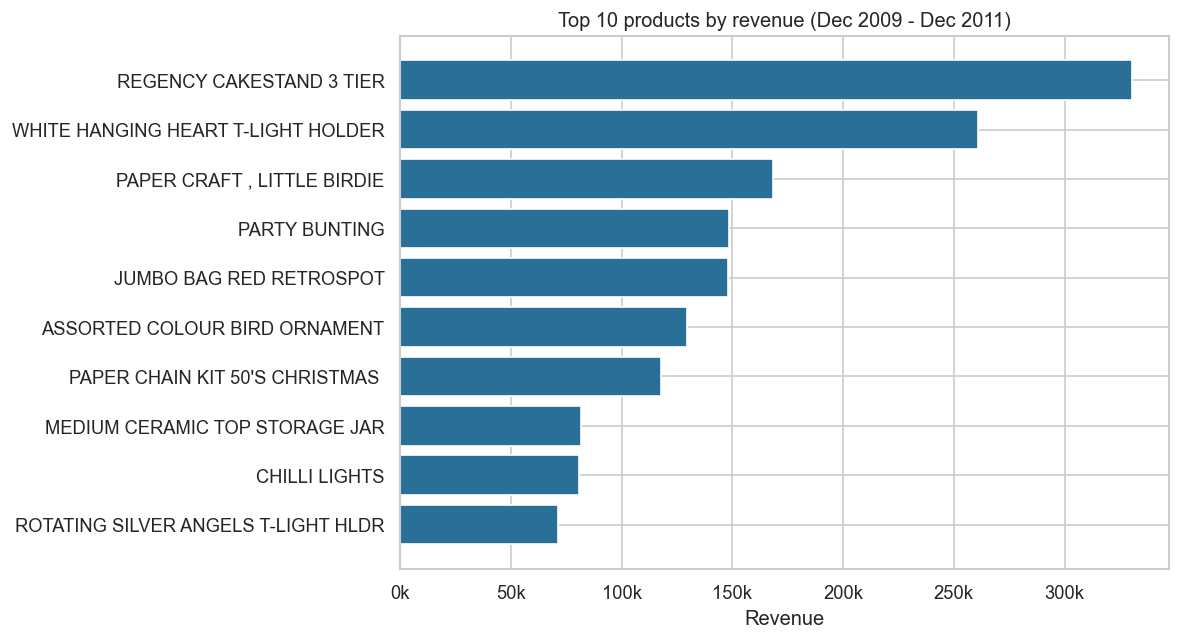

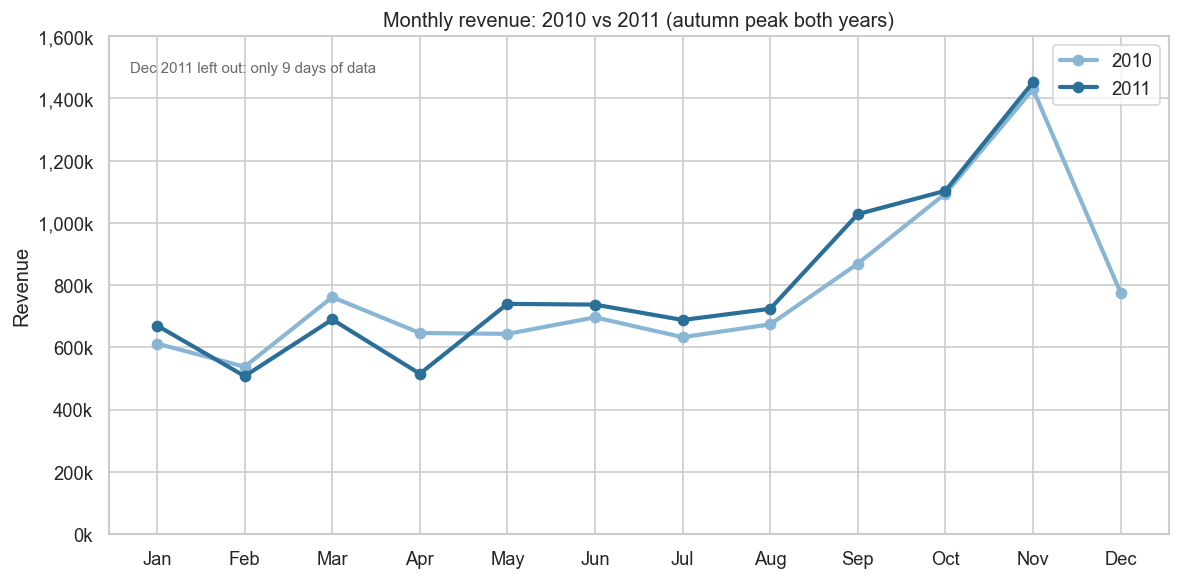

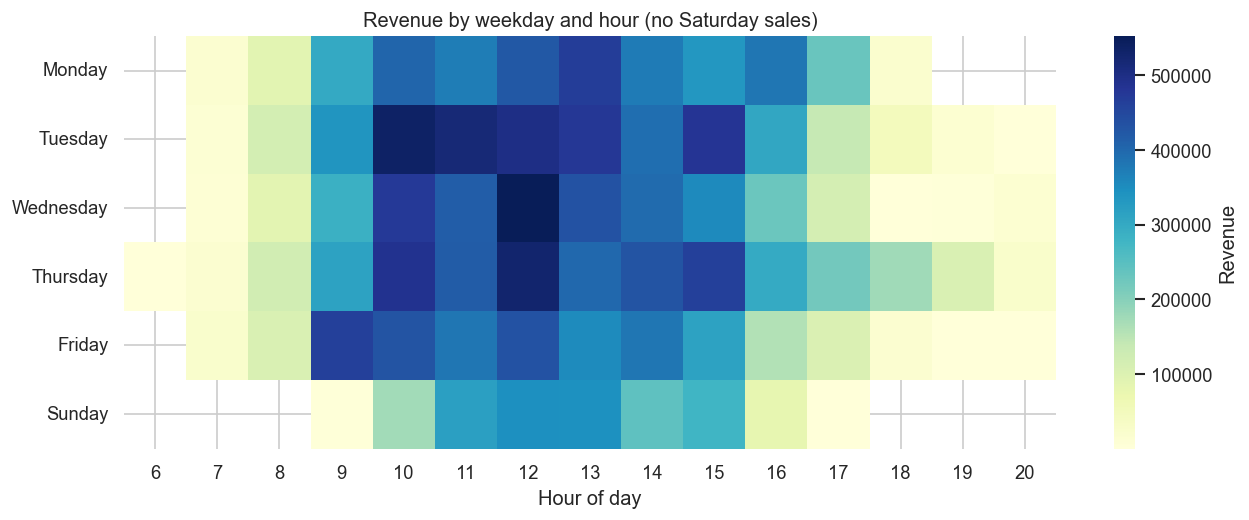

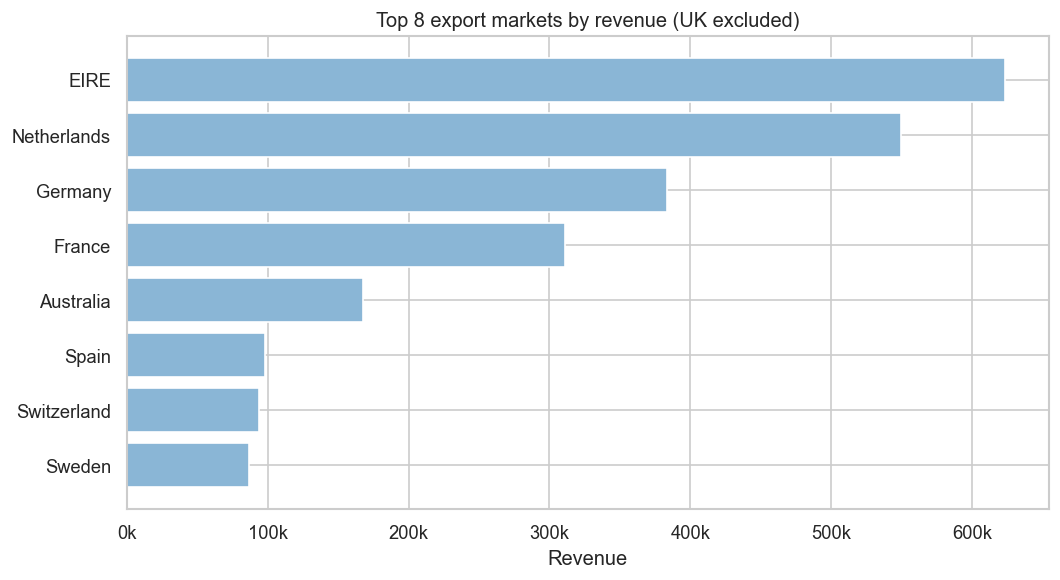

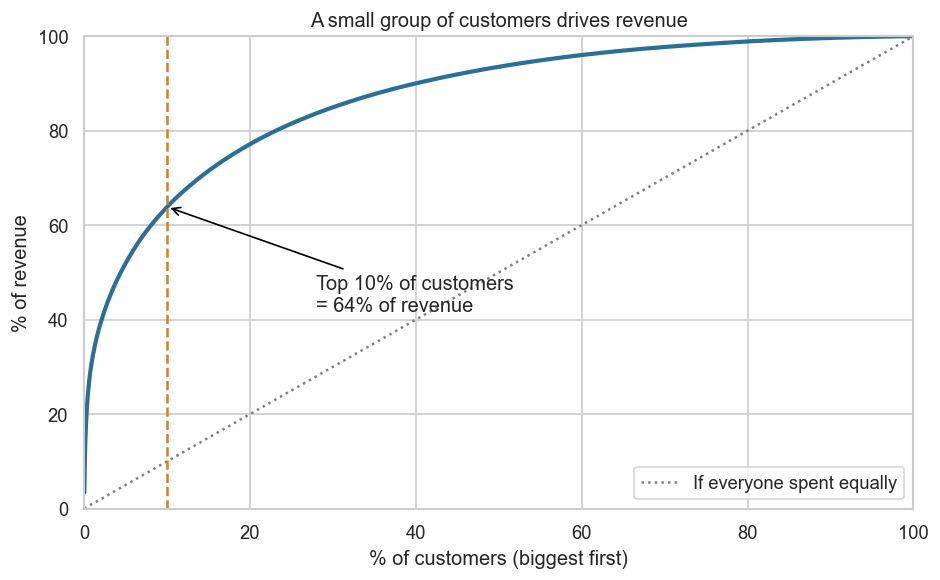

Charts saved in: c:\Users\sv2707920\OneDrive - Surbana Jurong Private Limited\Desktop\Data Science\Portfolio - Projects\Online Retail - Project\charts


In [12]:
# Online Retail project: Day 5 (charts, version 2 for the two-year data)
# Run cell by cell in your project folder, after Day 3 saved the result_*.csv files.
# Charts are saved as PNGs in a "charts" folder, ready for GitHub.

# %% Cell 1: Setup and load
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

try:
    folder = Path(__file__).resolve().parent
except NameError:
    folder = Path.cwd()

charts = folder / "charts"
charts.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["savefig.bbox"] = "tight"
BLUE, LIGHT, ORANGE = "#2a6f97", "#8ab6d6", "#e07a1f"

def thousands(x, _pos):
    return f"{x/1000:,.0f}k"

sales = pd.read_csv(folder / "clean_sales.csv", parse_dates=["InvoiceDate"])
sales["Year"] = sales["InvoiceDate"].dt.year
sales["MonthNum"] = sales["InvoiceDate"].dt.month
products = pd.read_csv(folder / "result_products.csv", index_col=0)
countries = pd.read_csv(folder / "result_countries.csv", index_col=0)
customers = pd.read_csv(folder / "result_customers.csv", index_col=0)

# Dec 2011 only has 9 days, so it is left out of month comparisons
complete = sales[sales["Month"] != "2011-12"]

# %% Chart 1: Top 10 products by revenue
top10 = products.head(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(top10.index[::-1], top10["Revenue"][::-1], color=BLUE)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(thousands))
ax.set_title("Top 10 products by revenue (Dec 2009 - Dec 2011)")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(charts / "chart1_top_products.png")
plt.show()

# %% Chart 2: Monthly revenue, 2010 vs 2011
by_month = (
    complete[complete["Year"].isin([2010, 2011])]
    .pivot_table(index="MonthNum", columns="Year", values="Revenue", aggfunc="sum")
)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(by_month.index, by_month[2010], marker="o", color=LIGHT, label="2010", linewidth=2.5)
ax.plot(by_month.index, by_month[2011], marker="o", color=BLUE, label="2011", linewidth=2.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(thousands))
ax.set_title("Monthly revenue: 2010 vs 2011 (autumn peak both years)")
ax.set_ylabel("Revenue")
ax.legend()
ax.set_ylim(0, 1600000)
ax.text(0.02, 0.95, "Dec 2011 left out: only 9 days of data",
        transform=ax.transAxes, fontsize=9, va="top", color="dimgray")
plt.tight_layout()
plt.savefig(charts / "chart2_monthly_revenue.png")
plt.show()

# %% Chart 3: When do customers buy? (weekday x hour heatmap)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Sunday"]
heat = (
    sales.pivot_table(index="Weekday", columns="Hour", values="Revenue", aggfunc="sum")
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(heat, cmap="YlGnBu", ax=ax, cbar_kws={"label": "Revenue"})
ax.set_title("Revenue by weekday and hour (no Saturday sales)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(charts / "chart3_weekday_hour_heatmap.png")
plt.show()

# %% Chart 4: Top export markets (excluding the UK, which is 85% of revenue)
others = countries.drop(index="United Kingdom", errors="ignore").head(8)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(others.index[::-1], others["Revenue"][::-1], color=LIGHT)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(thousands))
ax.set_title("Top 8 export markets by revenue (UK excluded)")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(charts / "chart4_export_markets.png")
plt.show()

# %% Chart 5: How concentrated is revenue among customers?
revenue_sorted = customers["Revenue"].sort_values(ascending=False)
cum_share = revenue_sorted.cumsum() / revenue_sorted.sum() * 100
pct_customers = pd.Series(range(1, len(cum_share) + 1)) / len(cum_share) * 100
top10_share = cum_share.iloc[int(len(cum_share) * 0.10) - 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pct_customers.values, cum_share.values, color=BLUE, linewidth=2.5)
ax.plot([0, 100], [0, 100], linestyle=":", color="gray", label="If everyone spent equally")
ax.axvline(10, linestyle="--", color=ORANGE)
ax.annotate(f"Top 10% of customers\n= {top10_share:.0f}% of revenue",
            xy=(10, top10_share), xytext=(28, top10_share - 22),
            arrowprops=dict(arrowstyle="->", color="black"))
ax.set_title("A small group of customers drives revenue")
ax.set_xlabel("% of customers (biggest first)")
ax.set_ylabel("% of revenue")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(charts / "chart5_customer_concentration.png")
plt.show()

print("Charts saved in:", charts)